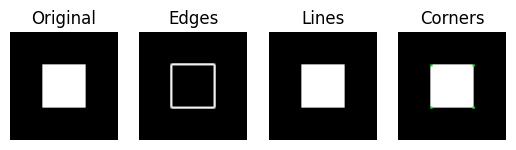

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create simple image (white square)
img = np.zeros((100,100), dtype=np.uint8)
img[30:70,30:70] = 255

# --------------------
# 1. Edge Detection (Sobel)
# --------------------
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1)
edges = cv2.magnitude(sobelx, sobely)

# --------------------
# 2. Line Detection (Hough)
# --------------------
edges_uint8 = np.uint8(edges)
lines = cv2.HoughLines(edges_uint8, 1, np.pi/180, 100)

img_lines = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

if lines is not None:
    for rho, theta in lines[:,0]:
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1 = int(x0 + 100*(-b))
        y1 = int(y0 + 100*(a))
        x2 = int(x0 - 100*(-b))
        y2 = int(y0 - 100*(a))
        cv2.line(img_lines, (x1,y1), (x2,y2), (0,0,255), 1)

# --------------------
# 3. Corner Detection (Harris)
# --------------------
img_float = np.float32(img)
corners = cv2.cornerHarris(img_float, 2, 3, 0.04)

img_corners = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
img_corners[corners > 0.01 * corners.max()] = [0,255,0]

# --------------------
# Display Results
# --------------------
plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(img_lines)
plt.title("Lines")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(img_corners)
plt.title("Corners")
plt.axis("off")

plt.show()